# Thesis Findings - E1 Simple Plot & Big Font

Combines two chart-legibility variants of the original Spotify pie chart into one notebook,
for the two models that were tested on both (Gemma-E4B, Qwen3-VL-8B): a **simplified chart**
(fewer slices) and that same simplified chart with a **bigger font**. For each, two very
different things exist and get contrasted directly:

- **Phase 1** (`benchmarking_simple_plot/`, `benchmarking_simple_plot_bigfont/`) — single-image
  fact-check accuracy: does the model say a caption is correct/incorrect, no comparison, no
  engagement shown at all.
- **Phase 2** (`experiments/e1_simple_plot/`, `experiments/e1_simple_plot_bigfont/`) — the full
  paired A/B grid, same design as the main study (7x7 engagement scales x 100 image pairs x
  metrics/likes-only conditions), run on these same two chart variants.

Both exist for both chart variants, so every comparison below is same-chart, not a proxy from
the original chart.


In [1]:
import json, csv, re
from pathlib import Path
from collections import defaultdict

REPO_ROOT = next(p for p in [Path().resolve(), *Path().resolve().parents]
                 if (p / "experiments/e1").is_dir())

MODELS = [("Gemma-E4B", "gemma4-e4b"), ("Qwen3-VL-8B", "qwen3-vl-8b")]
BENCH_SLUG_MAP = {"gemma4-e4b": "gemma-e4b"}  # benchmarking/ trees name this one model differently

CHART_TREES = [
    ("Original", "experiments/e1", "benchmarking"),
    ("Simplified", "experiments/e1_simple_plot", "benchmarking_simple_plot"),
    ("Big font", "experiments/e1_simple_plot_bigfont", "benchmarking_simple_plot_bigfont"),
]

SCALES = [0, 10, 100, 1000, 10000, 100000, 1000000]


def load_paired_grid(path):
    grid = defaultdict(list)
    for r in json.loads(Path(path).read_text()):
        grid[(r["correct_scale"], r["incorrect_scale"])].append(r["liked_variant"] == "correct")
    return grid


def cell_pct(grid, cs, ics):
    vals = grid.get((cs, ics))
    if not vals:
        return None
    return 100 * sum(vals) / len(vals), len(vals)


def opposite_corner_effect_score(path):
    """Same construction as the main study's opposite-corner test: 1 - (disadvantaged/advantaged),
    averaged over all 21 off-diagonal pairs. 0 = no conformity, 1 = fully overridden by engagement."""
    if not Path(path).exists():
        return None
    grid = load_paired_grid(path)
    scores = []
    for cs in SCALES:
        for ics in SCALES:
            if cs >= ics:
                continue
            d, a = cell_pct(grid, cs, ics), cell_pct(grid, ics, cs)
            if not d or not a:
                continue
            scores.append(1.0 - (d[0] / a[0]) if a[0] > 0 else 0.0)
    return sum(scores) / len(scores) if scores else None


def diagonal_accuracy_by_slot(path):
    """Zero-engagement-disparity accuracy, split by which slot held the correct post, plus a
    pooled number -- same method used throughout the other overview notebooks this session."""
    if not Path(path).exists():
        return None
    data = json.loads(Path(path).read_text())
    diag = [r for r in data if r["correct_scale"] == r["incorrect_scale"]]
    by_slot = defaultdict(list)
    for r in diag:
        slot = "A" if r["post_a_variant"] == "correct" else "B"
        by_slot[slot].append(r["liked_variant"] == "correct")
    out = {}
    for slot, vals in by_slot.items():
        n, k = len(vals), sum(vals)
        out[slot] = (100 * k / n, n)
    n_all, k_all = len(diag), sum(1 for r in diag if r["liked_variant"] == "correct")
    out["pooled"] = (100 * k_all / n_all, n_all) if n_all else (None, 0)
    return out


def phase1_post_claim_accuracy(bench_tree, slug, test_dir="test-1-gn-news-extensive"):
    """Pooled post_claim (fact-check) accuracy across the standard v1-v6 prompt sweep."""
    bench_slug = BENCH_SLUG_MAP.get(slug, slug)
    base = REPO_ROOT / bench_tree / "outputs" / bench_slug / "quantitative" / test_dir
    if not base.exists():
        return None
    pattern = re.compile(r"v\d+")
    vals = []
    for version_dir in sorted(base.iterdir()):
        if not pattern.fullmatch(version_dir.name):
            continue
        for csv_path in version_dir.glob("accuracy_scores_v*.csv"):
            with open(csv_path, newline="") as f:
                for row in csv.DictReader(f):
                    if "post_claim_correct_correct" in row:
                        vals.append(row["post_claim_correct_correct"] == "True")
    return 100 * sum(vals) / len(vals) if vals else None


print(f"root: {REPO_ROOT}")
print(f"{len(MODELS)} models x {len(CHART_TREES)} chart variants ready")


root: /home/jovyan/conformity-llms-facebook-posts
2 models x 3 chart variants ready


## 1. Headline: does legibility fix the models' judgment, at any level?

Three separate numbers, same two models, same three charts, side by side:

- **Phase 1 fact-check %** — single post, no comparison, no engagement. Does simplifying the
  chart / enlarging the font help the model just say whether a caption is true?
- **Diagonal (baseline) %** — paired A/B, zero engagement difference. Split by screen slot to
  show whether the number is trustworthy or just a position habit (large gap = habit, not
  judgment).
- **Conformity effect score (0-1)** — the main study's headline metric, run on this exact
  chart. 0 = engagement doesn't move the model, 1 = engagement fully overrides correctness.

If legibility were the bottleneck, all three should improve together as the chart gets easier
to read. They don't.


In [2]:
print(f"{'chart':12s}{'model':14s}{'Phase1 fact-check %':>21s}{'diagonal pooled %':>19s}{'diagonal A/B gap':>18s}{'effect score':>14s}")
print("-" * 96)
for chart_label, e1_tree, bench_tree in CHART_TREES:
    for label, slug in MODELS:
        p1 = phase1_post_claim_accuracy(bench_tree, slug)
        diag = diagonal_accuracy_by_slot(REPO_ROOT / e1_tree / slug / "outputs" / "e1_results_metrics_paired.json")
        effect = opposite_corner_effect_score(REPO_ROOT / e1_tree / slug / "outputs" / "e1_results_metrics_paired.json")

        p1_str = f"{p1:.1f}" if p1 is not None else "-"
        if diag and "A" in diag and "B" in diag:
            pooled_str = f"{diag['pooled'][0]:.1f}"
            gap_str = f"{abs(diag['A'][0] - diag['B'][0]):.1f}"
        else:
            pooled_str = gap_str = "-"
        effect_str = f"{effect:.3f}" if effect is not None else "-"

        print(f"{chart_label:12s}{label:14s}{p1_str:>21s}{pooled_str:>19s}{gap_str:>18s}{effect_str:>14s}")
    print()


chart       model           Phase1 fact-check %  diagonal pooled %  diagonal A/B gap  effect score
------------------------------------------------------------------------------------------------
Original    Gemma-E4B                      25.0               52.3              97.1         0.988
Original    Qwen3-VL-8B                    41.7               55.0              83.6         0.983

Simplified  Gemma-E4B                      16.7               52.7              92.8         0.996
Simplified  Qwen3-VL-8B                    83.3               55.4              86.2         0.946

Big font    Gemma-E4B                      33.3               51.7              99.4         0.997
Big font    Qwen3-VL-8B                    75.0               50.9              95.0         0.938



## 2. Full grids — does the conformity effect itself change with legibility?

Same 7x7 heatmap style as the main study and climate notebooks, run on the simplified and
big-font charts directly (not the original). Hatched cells are position-driven and shouldn't
be read as conformity effects, same convention as everywhere else.


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_simple_plot_bigfont/outputs/simple_bigfont_grid_overview.png


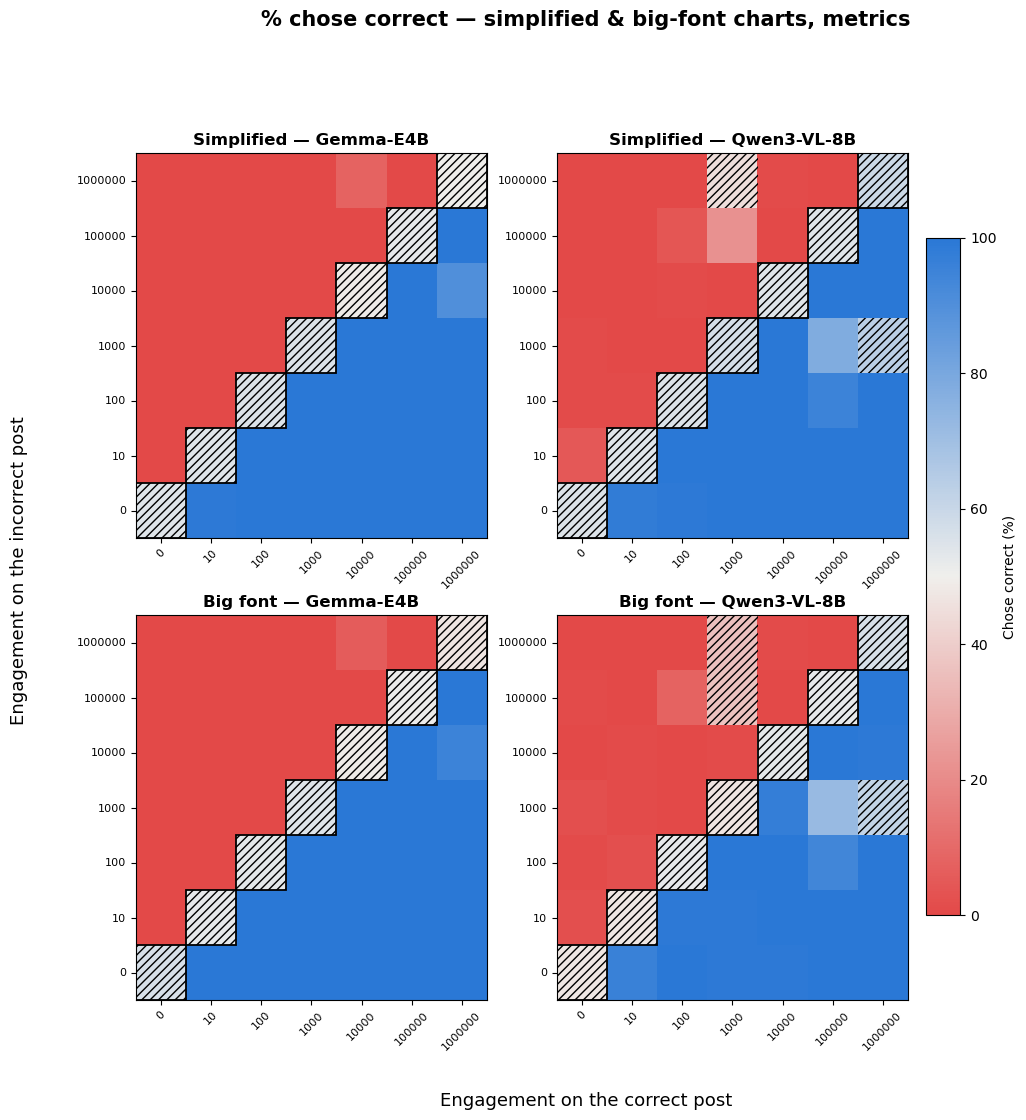

In [3]:
def simplechart_grid_matrix(e1_tree, slug, condition="metrics"):
    f = REPO_ROOT / e1_tree / slug / "outputs" / f"e1_results_{condition}_paired.json"
    if not f.exists():
        return None, None, None
    data = json.loads(f.read_text())
    n_lv = len(SCALES)
    pct = [[None] * n_lv for _ in range(n_lv)]
    gap = [[None] * n_lv for _ in range(n_lv)]
    cnt = [[0] * n_lv for _ in range(n_lv)]
    for i, ics in enumerate(SCALES):
        for j, cs in enumerate(SCALES):
            cell = [r for r in data if r["correct_scale"] == cs and r["incorrect_scale"] == ics]
            if not cell:
                continue
            cnt[i][j] = len(cell)
            pct[i][j] = 100 * sum(1 for r in cell if r["liked_variant"] == "correct") / len(cell)
            halves = []
            for slot in ("A", "B"):
                half = [r for r in cell if (r["post_a_variant"] == "correct") == (slot == "A")]
                if half:
                    halves.append(100 * sum(1 for r in half if r["liked_variant"] == "correct") / len(half))
            gap[i][j] = abs(halves[0] - halves[1]) if len(halves) == 2 else None
    return pct, gap, cnt


def plot_simplechart_grid_overview(condition="metrics", position_gap_threshold=60.0, save_path=None):
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors

    n = len(SCALES)
    cmap = mcolors.LinearSegmentedColormap.from_list("red_gray_blue", ["#e34948", "#f0efec", "#2a78d6"])
    fig, axes = plt.subplots(2, 2, figsize=(12, 11))
    im = None

    panels = [(chart_label, e1_tree, label, slug)
              for chart_label, e1_tree, _ in CHART_TREES if chart_label != "Original"
              for label, slug in MODELS]

    for ax, (chart_label, e1_tree, label, slug) in zip(axes.flatten(), panels):
        pct, gap, cnt = simplechart_grid_matrix(e1_tree, slug, condition)
        if pct is None:
            ax.set_title(f"{chart_label} — {label} (no data)", fontsize=12, fontweight="bold")
            ax.axis("off")
            continue
        grid = np.array([[np.nan if v is None else v for v in row] for row in pct])
        im = ax.imshow(grid, cmap=cmap, vmin=0, vmax=100, aspect="auto")
        for i in range(n):
            for j in range(n):
                if gap[i][j] is not None and gap[i][j] >= position_gap_threshold:
                    ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, fill=False,
                                               hatch="////", edgecolor="black", linewidth=0))
            ax.add_patch(plt.Rectangle((i - .5, i - .5), 1, 1, fill=False,
                                       edgecolor="black", linewidth=1.3))
        ax.set_title(f"{chart_label} — {label}", fontsize=12, fontweight="bold")
        ax.set_xticks(range(n)); ax.set_yticks(range(n))
        ax.set_xticklabels([str(s) for s in SCALES], fontsize=8, rotation=45)
        ax.set_yticklabels([str(s) for s in SCALES], fontsize=8)
        ax.invert_yaxis()

    fig.supxlabel("Engagement on the correct post", fontsize=13)
    fig.supylabel("Engagement on the incorrect post", fontsize=13)
    fig.suptitle(f"% chose correct — simplified & big-font charts, {condition}", fontsize=15, fontweight="bold", y=1.01)
    if im is not None:
        fig.colorbar(im, ax=axes.flatten().tolist(), shrink=0.8, pad=0.02, label="Chose correct (%)")

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"✅ Saved to: {save_path}")
    plt.show()


plot_simplechart_grid_overview(save_path=Path().resolve() / "outputs" / "simple_bigfont_grid_overview.png")


## 3. Phase 1 diagnostics — what's actually going wrong on isolated posts

Same diagnostics used in the individual `benchmarking_simple_plot*` notebooks, reused here so
both chart variants are visible side by side instead of in two separate notebooks.


In [4]:
for chart_label, e1_tree, bench_tree in CHART_TREES:
    if chart_label == "Original":
        continue
    print(f"\n{'='*90}\n{chart_label} chart — struggling questions (pooled v1-v6)\n{'='*90}")
    for label, slug in MODELS:
        bench_slug = BENCH_SLUG_MAP.get(slug, slug)
        base = REPO_ROOT / bench_tree / "outputs" / bench_slug / "quantitative/test-1-gn-news-extensive"
        question_scores = {}
        for v in range(1, 7):
            fp = base / f"v{v}" / f"accuracy_scores_v{v}.csv"
            if not fp.exists():
                continue
            with open(fp, newline="") as f:
                for row in csv.DictReader(f):
                    for k, v_ in row.items():
                        if not k.endswith("_correct") or k == "all_correct":
                            continue
                        q = k.replace("_correct", "")
                        question_scores.setdefault(q, []).append(100.0 if v_ == "True" else 0.0)
        struggling = [(q, sum(s) / len(s), len(s)) for q, s in question_scores.items() if s and sum(s) / len(s) < 100.0]
        struggling.sort(key=lambda r: r[1])
        print(f"\n--- {label} ---")
        if not struggling:
            print("  No questions under 100% accuracy.")
        for q, acc, n in struggling:
            print(f"  {q:24s} {acc:6.2f}%  (n={n})")



Simplified chart — struggling questions (pooled v1-v6)

--- Gemma-E4B ---
  likes_count                0.00%  (n=12)
  wow_reactions              0.00%  (n=12)
  sad_reactions              0.00%  (n=12)
  angry_reactions            0.00%  (n=12)
  post_claim                16.67%  (n=12)

--- Qwen3-VL-8B ---
  post_claim                83.33%  (n=12)

Big font chart — struggling questions (pooled v1-v6)

--- Gemma-E4B ---
  likes_count                0.00%  (n=12)
  haha_reactions             0.00%  (n=12)
  sad_reactions              0.00%  (n=12)
  angry_reactions            0.00%  (n=12)
  post_claim                33.33%  (n=12)

--- Qwen3-VL-8B ---
  post_claim                75.00%  (n=12)


In [5]:
for chart_label, e1_tree, bench_tree in CHART_TREES:
    print(f"\n{'='*90}\n{chart_label} chart — post_claim accuracy by post variant\n{'='*90}")
    if chart_label == "Original":
        print("(restricted to the 2 plain-Remy images -- the original chart also has 2 'Dr.' images")
        print(" that were never re-tested on the simplified charts, excluded here for a fair comparison)")
    print(f"{'model':14s}{'correct-post %':>16s}{'incorrect-post %':>18s}{'gap (incorrect-correct)':>26s}")
    for label, slug in MODELS:
        bench_slug = BENCH_SLUG_MAP.get(slug, slug)
        base = REPO_ROOT / bench_tree / "outputs" / bench_slug / "quantitative/test-1-gn-news-extensive"
        variant_scores = {"correct": [], "incorrect": []}
        for v in range(1, 7):
            fp = base / f"v{v}" / f"accuracy_scores_v{v}.csv"
            if not fp.exists():
                continue
            with open(fp, newline="") as f:
                for row in csv.DictReader(f):
                    if "post_claim_correct_correct" not in row or "variant" not in row:
                        continue
                    if chart_label == "Original" and not row["image"].startswith("001_remy_ashford"):
                        continue
                    variant_scores.setdefault(row["variant"], []).append(100.0 if row["post_claim_correct_correct"] == "True" else 0.0)
        c, i = variant_scores.get("correct", []), variant_scores.get("incorrect", [])
        c_acc = sum(c) / len(c) if c else None
        i_acc = sum(i) / len(i) if i else None
        gap = (i_acc - c_acc) if c_acc is not None and i_acc is not None else None
        c_str = f"{c_acc:.2f}" if c_acc is not None else "-"
        i_str = f"{i_acc:.2f}" if i_acc is not None else "-"
        g_str = f"{gap:+.2f}" if gap is not None else "-"
        print(f"{label:14s}{c_str:>16s}{i_str:>18s}{g_str:>26s}")



Simplified chart — post_claim accuracy by post variant
model           correct-post %  incorrect-post %   gap (incorrect-correct)
Gemma-E4B                33.33              0.00                    -33.33
Qwen3-VL-8B              66.67            100.00                    +33.33

Big font chart — post_claim accuracy by post variant
model           correct-post %  incorrect-post %   gap (incorrect-correct)
Gemma-E4B                66.67              0.00                    -66.67
Qwen3-VL-8B              66.67             83.33                    +16.67


## Key findings

1. **Legibility helps isolated fact-checking, unevenly.** Qwen3-VL-8B's Phase 1 post_claim
   accuracy jumps from 33.3% (original chart) to 83.3% (simplified) to 75.0% (big font) —
   simplifying clearly helps this model, the bigger font gives a little back. Gemma-E4B moves
   the opposite way at first (25.0% → 16.7%) before the bigger font recovers it (33.3%).

2. **None of that carries over to the paired diagonal.** Both models sit at 51–55% pooled
   diagonal accuracy on *every* chart version, and in every case the real story is an 84–99
   point gap between "correct post in slot A" and "correct post in slot B" — a screen-position
   habit, not judgment. Making the chart easier to read never touches this.

3. **The conformity effect itself is untouched too.** Effect scores stay in the 0.94–0.997
   range for both models across all three chart versions — legibility doesn't reduce
   susceptibility to fake engagement at all, only (sometimes) isolated fact-checking accuracy.

4. **Read together, this closes the "maybe it's just legibility" question.** Two completely
   different failure modes (screen-position defaulting at ties, and popularity overriding
   correctness once any disparity exists) are both unaffected by chart simplicity or font
   size, on the same models, same charts, same trials. Whatever is driving both isn't
   perceptual difficulty — it's how the decision gets made once the post is legible.
